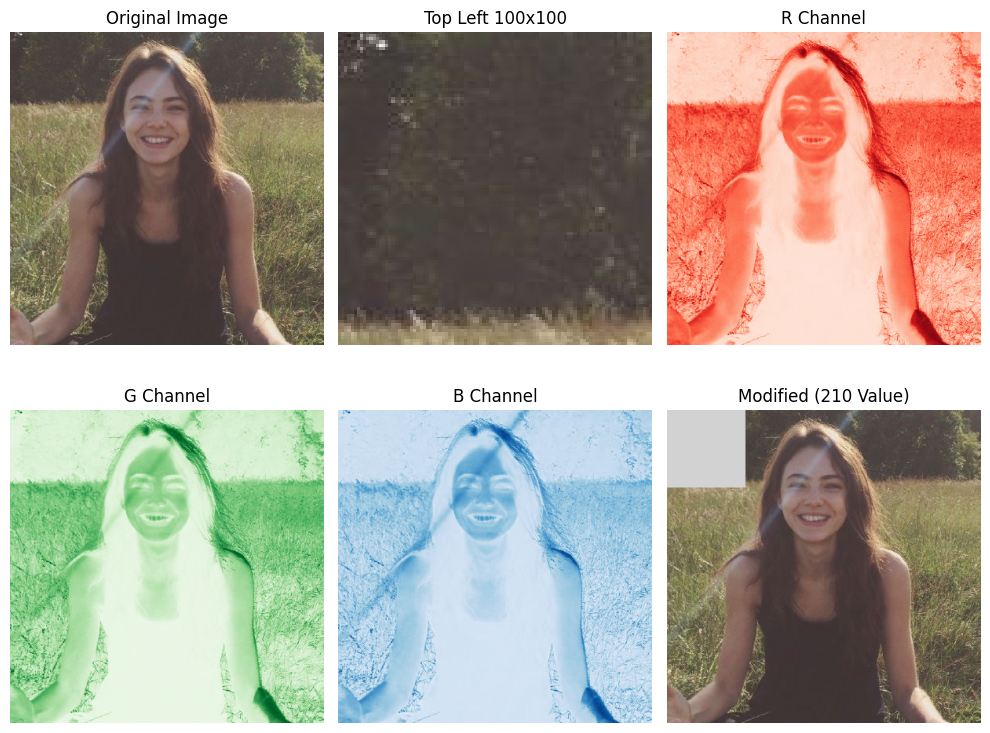

In [1]:
#Exercise 1
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Read and display the image
img = Image.open('image.jpg')
img_array = np.array(img)

plt.figure(figsize=(10, 8))
plt.subplot(2, 3, 1)
plt.imshow(img_array)
plt.title("Original Image")
plt.axis('off')

# Display top-left corner of 100x100 pixels
top_left = img_array[0:100, 0:100, :]

plt.subplot(2, 3, 2)
plt.imshow(top_left)
plt.title("Top Left 100x100")
plt.axis('off')

# Show the three color channels (R, G, B) using NumPy

red_channel = img_array[:, :, 0]
green_channel = img_array[:, :, 1]
blue_channel = img_array[:, :, 2]

# Display Red
plt.subplot(2, 3, 3)
plt.imshow(red_channel, cmap='Reds')
plt.title("R Channel")
plt.axis('off')

# Display Green
plt.subplot(2, 3, 4)
plt.imshow(green_channel, cmap='Greens')
plt.title("G Channel")
plt.axis('off')

# Display Blue
plt.subplot(2, 3, 5)
plt.imshow(blue_channel, cmap='Blues')
plt.title("B Channel")
plt.axis('off')

# Modify top 100x100 pixels to 210 (Light Gray)

modified_img = img_array.copy()
modified_img[0:100, 0:100, :] = 210

plt.subplot(2, 3, 6)
plt.imshow(modified_img)
plt.title("Modified (210 Value)")
plt.axis('off')

plt.tight_layout()
plt.show()

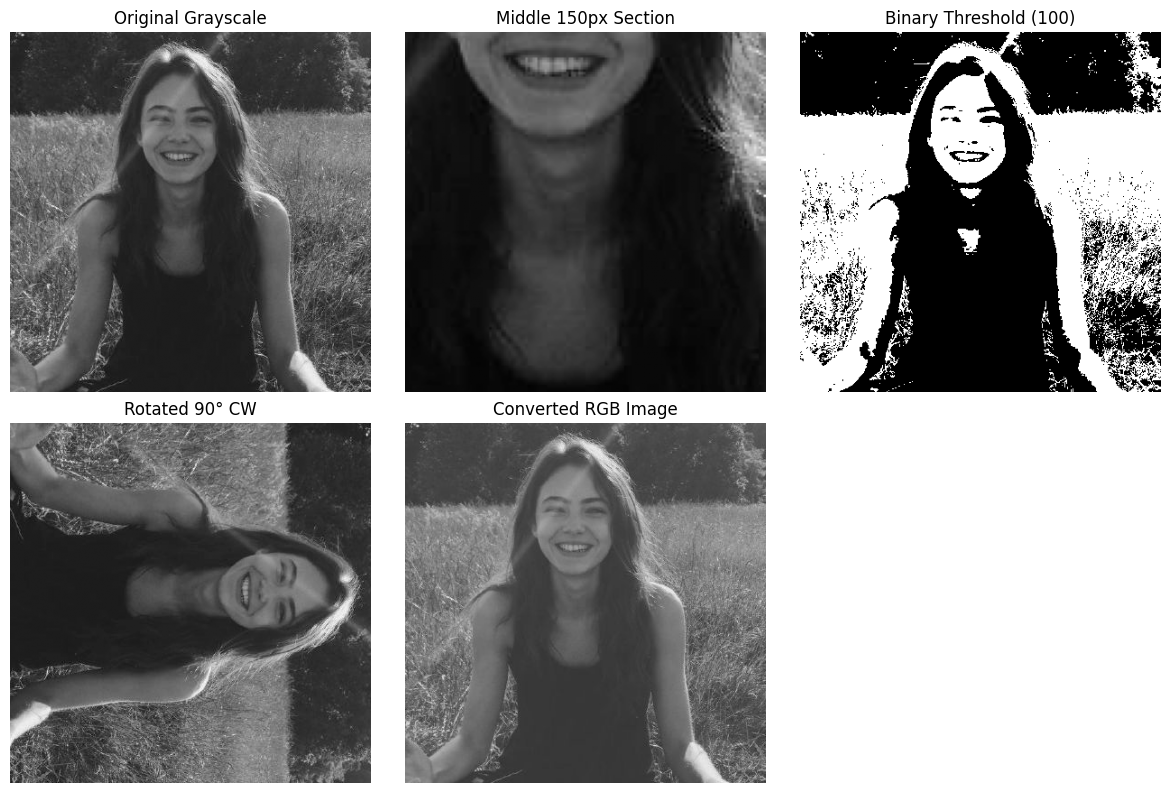

In [2]:
#Exercise 2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load and display a grayscale image
# mode in Pillow opens the image directly in grayscale
img_gray = Image.open('image.jpg').convert('L')
img_array = np.array(img_gray)

plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.imshow(img_array, cmap='gray')
plt.title("Original Grayscale")
plt.axis('off')

# Extract and display the middle 150x150 pixels
h, w = img_array.shape
center_h, center_w = h // 2, w // 2
# Calculating bounds for a 150px square
crop = img_array[center_h-75:center_h+75, center_w-75:center_w+75]

plt.subplot(2, 3, 2)
plt.imshow(crop, cmap='gray')
plt.title("Middle 150px Section")
plt.axis('off')

# Simple Thresholding (Binary Image)
# We create a mask where values > 100 become 255, else 0
binary_img = np.where(img_array > 100, 255, 0).astype(np.uint8)

plt.subplot(2, 3, 3)
plt.imshow(binary_img, cmap='gray')
plt.title("Binary Threshold (100)")
plt.axis('off')

# Rotate 90 degrees clockwise
# In Pillow, rotate() is counter-clockwise by default, so use -90 or 270
rotated_img = img_gray.rotate(-90, expand=True)

plt.subplot(2, 3, 4)
plt.imshow(rotated_img, cmap='gray')
plt.title("Rotated 90° CW")
plt.axis('off')

# Convert Grayscale to RGB
# We stack the grayscale array 3 times along a new third axis
rgb_converted = np.stack([img_array] * 3, axis=-1)

plt.subplot(2, 3, 5)
plt.imshow(rgb_converted)
plt.title("Converted RGB Image")
plt.axis('off')

plt.tight_layout()
plt.show()

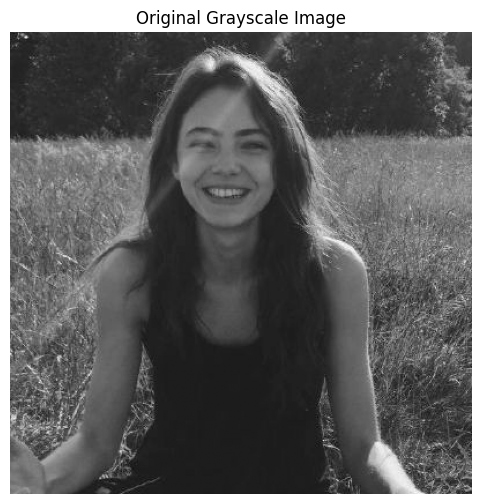

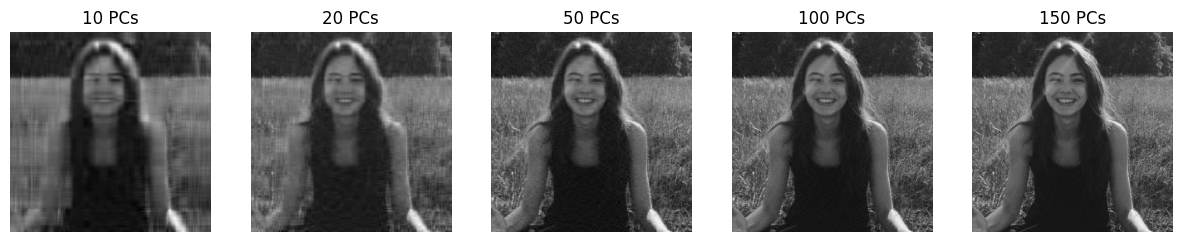

In [4]:
#Exercise 3
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load Image and Convert to Grayscale
img = Image.open('image.jpg').convert('L')
data = np.array(img, dtype=float)

# Display Original Image
plt.figure(figsize=(6, 6))
plt.imshow(data, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')
plt.show()

#  Center the Data
mean = np.mean(data, axis=0)
data_centered = data - mean

# Covariance Matrix and Eigen Decomposition
cov_matrix = np.cov(data_centered, rowvar=False)
values, vectors = np.linalg.eigh(cov_matrix)

# Sort eigenvalues and eigenvectors descending
idx = np.argsort(values)[::-1]
vectors = vectors[:, idx]

# Rebuild Image Function using top k principal components
def rebuild(k):
    top_vectors = vectors[:, :k]
    compressed = np.dot(data_centered, top_vectors)
    reconstructed = np.dot(compressed, top_vectors.T) + mean
    return reconstructed

# Display Reconstructed Images with Different k
ks = [10, 20, 50, 100, 150]
plt.figure(figsize=(15, 4))

for i, k in enumerate(ks):
    plt.subplot(1, len(ks), i + 1)
    plt.imshow(rebuild(k), cmap='gray')
    plt.title(f"{k} PCs")
    plt.axis('off')

plt.show()